# Notebook 1 — Encoder–Decoder e Autoencoders

**Objetivos:** entender a arquitetura encoder–decoder, treinar um autoencoder no MNIST, explorar o espaço latente e usar a mesma ideia para remover ruído de imagens.

> Tudo o que não é o tópico central (dados, gráficos) está abstraído em `aula_generativa.py` — as células mostram apenas o essencial.

## 0. Preparação do ambiente

Este notebook roda **localmente** e no **Google Colab**. A célula abaixo é só infraestrutura: ela garante o módulo de apoio `aula_generativa.py` (carregamento de dados, gráficos e a "cirurgia" na VGG ficam lá, fora do foco da aula). No Colab a célula aparece **recolhida** — basta executá-la e seguir em frente.


In [1]:
# >>> infra-colab-aula-generativa >>>
#@title ⚙️ Infraestrutura: módulo de apoio (execute e siga em frente) { display-mode: "form" }
import os
_APOIO = r'''

# -*- coding: utf-8 -*-
"""
Biblioteca de apoio da Aula Generativa (Encoder-Decoder, Style Transfer e GANs).

Tudo o que NÃO é o tópico central da aula (carregamento de dados, plotagem,
montagem do modelo VGG para style transfer, downloads) fica abstraído aqui,
para que os notebooks tenham apenas células pequenas e didáticas.
"""

import os
import urllib.request

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

# ----------------------------------------------------------------------
# Dispositivo e reprodutibilidade
# ----------------------------------------------------------------------

def dispositivo():
    """Retorna o melhor dispositivo disponível (MPS no Apple Silicon, CUDA ou CPU)."""
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def semente(seed=42):
    """Fixa a semente aleatória para reduzir a variabilidade entre execuções.

    `torch.manual_seed` já cobre CPU, CUDA e MPS, além do embaralhamento do
    DataLoader. (Em GPU, o cuDNN ainda pode introduzir pequena não-determinância.)
    """
    torch.manual_seed(seed)
    np.random.seed(seed)


# ----------------------------------------------------------------------
# Dados
# ----------------------------------------------------------------------

_DATA_DIR = os.path.join(os.path.dirname(os.path.abspath(__file__)), "_data")


def carregar_mnist(batch_size=128, n_amostras=None, normalizar_11=False):
    """DataLoader do MNIST.

    normalizar_11=True deixa os pixels em [-1, 1] (necessário para a GAN,
    cujo gerador termina em Tanh). Caso contrário, pixels em [0, 1].
    """
    if normalizar_11:
        tf = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.5,), (0.5,))])
    else:
        tf = transforms.ToTensor()
    ds = datasets.MNIST(root=_DATA_DIR, train=True, download=True, transform=tf)
    if n_amostras is not None:
        ds = Subset(ds, range(n_amostras))
    return DataLoader(ds, batch_size=batch_size, shuffle=True)


# ----------------------------------------------------------------------
# Visualização
# ----------------------------------------------------------------------

def mostrar_grade(imgs, titulo=None, n=8, desnormalizar=False):
    """Mostra um lote de imagens em grade. Aceita tensor (B, C, H, W)."""
    imgs = imgs.detach().cpu()[:n * n]
    if desnormalizar:
        imgs = imgs / 2 + 0.5
    grade = torchvision.utils.make_grid(imgs, nrow=n, padding=2)
    plt.figure(figsize=(7, 7))
    plt.imshow(np.transpose(grade.clamp(0, 1).numpy(), (1, 2, 0)))
    plt.axis("off")
    if titulo:
        plt.title(titulo)
    plt.show()


def comparar_linhas(linhas, titulos, n=8):
    """Mostra listas de imagens em linhas comparáveis (ex.: original x reconstruída)."""
    fig, axes = plt.subplots(len(linhas), n, figsize=(1.3 * n, 1.5 * len(linhas)))
    for i, (lote, titulo) in enumerate(zip(linhas, titulos)):
        lote = lote.detach().cpu()
        for j in range(n):
            ax = axes[i, j] if len(linhas) > 1 else axes[j]
            ax.imshow(lote[j].squeeze().clamp(0, 1).numpy(), cmap="gray")
            ax.axis("off")
            if j == 0:
                ax.set_title(titulo, loc="left", fontsize=10)
    plt.tight_layout()
    plt.show()


def curva(valores, xlabel="época", ylabel="perda", titulo=None, rotulos=None):
    """Plota uma ou mais curvas de treinamento."""
    if not valores:
        return
    plt.figure(figsize=(6, 3.5))
    if isinstance(valores[0], (list, tuple, np.ndarray)):
        for serie, rot in zip(valores, rotulos or [None] * len(valores)):
            plt.plot(serie, label=rot)
        if rotulos:
            plt.legend()
    else:
        plt.plot(valores)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if titulo:
        plt.title(titulo)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def ruido(imgs, intensidade=0.5):
    """Adiciona ruído gaussiano a um lote de imagens em [0, 1]."""
    return (imgs + intensidade * torch.randn_like(imgs)).clamp(0, 1)


def interpolar_latente(decoder, z1, z2, passos=10):
    """Decodifica interpolações lineares entre dois vetores latentes.

    `decoder` pode ser o decoder do autoencoder ou o gerador G de uma GAN.
    z1, z2 têm forma (1, dim_latente) — ou (1, dim, 1, 1) para geradores
    convolucionais; o reshape de alfas se adapta à dimensionalidade de z.
    """
    alfas = torch.linspace(0, 1, passos, device=z1.device).view([-1] + [1] * (z1.dim() - 1))
    zs = (1 - alfas) * z1 + alfas * z2
    with torch.no_grad():
        return decoder(zs).cpu()


# ----------------------------------------------------------------------
# Imagens para Style Transfer
# ----------------------------------------------------------------------

_IMG_DIR = os.path.join(os.path.dirname(os.path.abspath(__file__)), "_imagens")

_URLS_EXEMPLO = {
    "conteudo.jpg": [
        # Neckarfront de Tübingen (a foto do artigo original de Gatys) e tartaruga (Wikimedia Commons)
        "https://commons.wikimedia.org/wiki/Special:FilePath/Tuebingen_Neckarfront.jpg?width=1024",
        "https://commons.wikimedia.org/wiki/Special:FilePath/Green_Sea_Turtle_grazing_seagrass.jpg?width=1024",
    ],
    "estilo.jpg": [
        # A Noite Estrelada, van Gogh (domínio público)
        "https://commons.wikimedia.org/wiki/Special:FilePath/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg?width=1024",
        "https://commons.wikimedia.org/wiki/Special:FilePath/The_Great_Wave_off_Kanagawa.jpg?width=1024",
    ],
}


def baixar_imagens_exemplo():
    """Baixa uma imagem de conteúdo e uma de estilo (Wikimedia Commons).

    Retorna (caminho_conteudo, caminho_estilo). Se os arquivos já existem,
    não baixa de novo.
    """
    os.makedirs(_IMG_DIR, exist_ok=True)
    caminhos = []
    for nome, urls in _URLS_EXEMPLO.items():
        destino = os.path.join(_IMG_DIR, nome)
        if not os.path.exists(destino):
            for url in urls:
                try:
                    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
                    with urllib.request.urlopen(req, timeout=30) as r, open(destino, "wb") as f:
                        f.write(r.read())
                    break
                except Exception as e:
                    print(f"Falha em {url[:60]}...: {e}")
        if not os.path.exists(destino):
            raise RuntimeError(
                f"Não foi possível baixar '{nome}'. Verifique a conexão ou copie "
                f"uma imagem manualmente para a pasta {_IMG_DIR}/."
            )
        caminhos.append(destino)
    return tuple(caminhos)


def carregar_imagem(caminho, tamanho=256, device=None):
    """Carrega uma imagem como tensor (1, 3, tamanho, tamanho) em [0, 1].

    Redimensiona para um quadrado `tamanho`x`tamanho`: conteúdo e estilo
    precisam ter a MESMA forma, porque os módulos de perda inseridos na VGG
    (ver `montar_modelo_estilo`) são atravessados pelas duas imagens. A leve
    distorção de proporção é aceitável para a demonstração.
    """
    tf = transforms.Compose([
        transforms.Resize((tamanho, tamanho)),
        transforms.ToTensor(),
    ])
    img = Image.open(caminho).convert("RGB")
    t = tf(img).unsqueeze(0)
    return t.to(device) if device is not None else t


def mostrar_imagens(tensores, titulos=None, figsize=(12, 5)):
    """Mostra lado a lado uma lista de tensores-imagem (1, 3, H, W)."""
    fig, axes = plt.subplots(1, len(tensores), figsize=figsize)
    if len(tensores) == 1:
        axes = [axes]
    for ax, t, titulo in zip(axes, tensores, titulos or [None] * len(tensores)):
        ax.imshow(t[0].detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy())
        ax.axis("off")
        if titulo:
            ax.set_title(titulo)
    plt.tight_layout()
    plt.show()


# ----------------------------------------------------------------------
# Montagem do modelo VGG para Style Transfer
# (a "cirurgia" na VGG fica abstraída aqui; as perdas ficam no notebook)
# ----------------------------------------------------------------------

_VGG_MEAN = torch.tensor([0.485, 0.456, 0.406])
_VGG_STD = torch.tensor([0.229, 0.224, 0.225])


class _Normalizacao(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.mean = _VGG_MEAN.view(-1, 1, 1).to(device)
        self.std = _VGG_STD.view(-1, 1, 1).to(device)

    def forward(self, img):
        return (img - self.mean) / self.std


def montar_modelo_estilo(classe_content_loss, classe_style_loss,
                         img_conteudo, img_estilo,
                         camadas_conteudo=("conv_4",),
                         camadas_estilo=("conv_1", "conv_2", "conv_3", "conv_4", "conv_5"),
                         device=None):
    """Monta a VGG-19 truncada com módulos de perda inseridos.

    Recebe as CLASSES ContentLoss e StyleLoss definidas no notebook (elas são
    o conteúdo didático) e devolve (modelo, lista_style_losses, lista_content_losses).
    """
    device = device or img_conteudo.device
    # models.vgg19() já devolve uma instância nova, então não é preciso copiar.
    cnn = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features.to(device).eval()

    modelo = nn.Sequential(_Normalizacao(device))
    perdas_estilo, perdas_conteudo = [], []

    i = 0
    for camada in cnn.children():
        if isinstance(camada, nn.Conv2d):
            i += 1
            nome = f"conv_{i}"
        elif isinstance(camada, nn.ReLU):
            nome = f"relu_{i}"
            camada = nn.ReLU(inplace=False)
        elif isinstance(camada, nn.MaxPool2d):
            nome = f"pool_{i}"
        else:
            raise RuntimeError(f"camada inesperada na VGG-19.features: {type(camada).__name__}")
        modelo.add_module(nome, camada)

        if nome in camadas_conteudo:
            alvo = modelo(img_conteudo).detach()
            perda = classe_content_loss(alvo)
            modelo.add_module(f"content_loss_{i}", perda)
            perdas_conteudo.append(perda)

        if nome in camadas_estilo:
            alvo = modelo(img_estilo).detach()
            perda = classe_style_loss(alvo)
            modelo.add_module(f"style_loss_{i}", perda)
            perdas_estilo.append(perda)

    # corta tudo que vem depois da última perda
    for j in range(len(modelo) - 1, -1, -1):
        if isinstance(modelo[j], (classe_content_loss, classe_style_loss)):
            break
    modelo = modelo[: j + 1]

    modelo.requires_grad_(False)
    return modelo, perdas_estilo, perdas_conteudo


# ----------------------------------------------------------------------
# Apoio às GANs
# ----------------------------------------------------------------------

def amostras_geradas(gerador, ruido_fixo, titulo=None):
    """Gera imagens a partir de um ruído fixo e as mostra em grade."""
    gerador.eval()
    with torch.no_grad():
        falsas = gerador(ruido_fixo).cpu()
    gerador.train()
    n = int(round(len(falsas) ** 0.5))  # grade quadrada a partir do tamanho do lote
    mostrar_grade(falsas, titulo=titulo, n=n, desnormalizar=True)


def treinar_gan(G, D, loader, epocas=3, dim_ruido=100, forma_ruido=None,
                lr=2e-4, device=None, ruido_fixo=None, mostrar_progresso=True):
    """Treina uma GAN com o MESMO loop adversarial visto no notebook.

    Útil para reaproveitar o loop com outras arquiteturas (ex.: DCGAN).
    forma_ruido: tupla extra do ruído, ex. (100, 1, 1) para geradores convolucionais.
    Retorna (perdas_D, perdas_G).

    Obs.: cada chamada cria otimizadores Adam novos (o estado/momento é zerado).
    Para *continuar* um treino, aumente `epocas` numa única chamada em vez de
    chamar a função repetidas vezes.
    """
    device = device or next(G.parameters()).device
    criterio = nn.BCELoss()
    otim_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    otim_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    forma = forma_ruido or (dim_ruido,)
    perdas_D, perdas_G = [], []

    for epoca in range(epocas):
        soma_D = soma_G = 0.0
        for reais, _ in loader:
            reais = reais.to(device)
            b = reais.size(0)
            uns = torch.ones(b, 1, device=device)
            zeros = torch.zeros(b, 1, device=device)

            # 1) treina o discriminador
            z = torch.randn(b, *forma, device=device)
            falsas = G(z)
            perda_D = criterio(D(reais).view(b, 1), uns) + \
                      criterio(D(falsas.detach()).view(b, 1), zeros)
            otim_D.zero_grad(); perda_D.backward(); otim_D.step()

            # 2) treina o gerador
            perda_G = criterio(D(falsas).view(b, 1), uns)
            otim_G.zero_grad(); perda_G.backward(); otim_G.step()

            soma_D += perda_D.item(); soma_G += perda_G.item()

        perdas_D.append(soma_D / len(loader)); perdas_G.append(soma_G / len(loader))
        print(f"época {epoca + 1}/{epocas} | perda D: {perdas_D[-1]:.3f} | perda G: {perdas_G[-1]:.3f}")
        if mostrar_progresso and ruido_fixo is not None:
            amostras_geradas(G, ruido_fixo, titulo=f"Amostras após a época {epoca + 1}")

    return perdas_D, perdas_G
'''
with open("aula_generativa.py", "w", encoding="utf-8") as _f:
    _f.write(_APOIO)
print("aula_generativa.py garantido (versão da aula).")


aula_generativa.py garantido (versão da aula).


In [2]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
from torch import nn
try:
    import aula_generativa as ag
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "Execute primeiro a célula de infraestrutura (a primeira célula de código).")

device = ag.dispositivo()
ag.semente(42)
device

device(type='mps')

## 1. Os dados

Dígitos manuscritos do MNIST: imagens 28×28 em tons de cinza, pixels em $[0, 1]$.

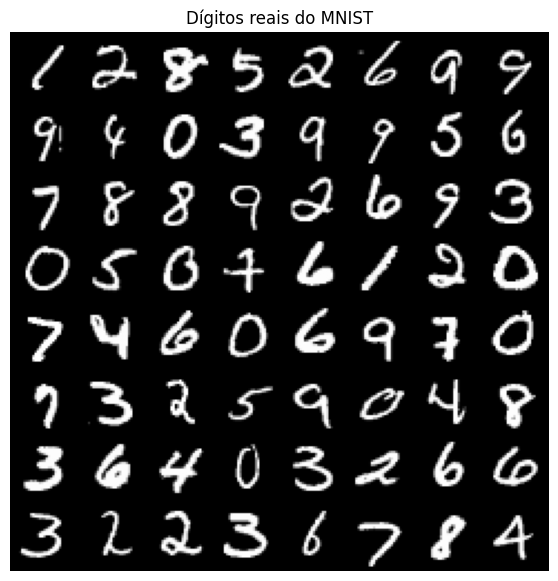

In [3]:
loader = ag.carregar_mnist(batch_size=128)
imagens, _ = next(iter(loader))
ag.mostrar_grade(imagens, titulo="Dígitos reais do MNIST")

## 2. O encoder: comprimir 784 pixels em 32 números

O **encoder** reduz a imagem a um vetor **latente** — um resumo 24× menor que a entrada.

In [4]:
DIM_LATENTE = 32

encoder = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256), nn.ReLU(),
    nn.Linear(256, DIM_LATENTE),
)

## 3. O decoder: reconstruir a imagem

O **decoder** faz o caminho inverso, $32 \to 784$. A `Sigmoid` final garante pixels em $[0, 1]$.

In [5]:
decoder = nn.Sequential(
    nn.Linear(DIM_LATENTE, 256), nn.ReLU(),
    nn.Linear(256, 784), nn.Sigmoid(),
    nn.Unflatten(1, (1, 28, 28)),
)

autoencoder = nn.Sequential(encoder, decoder).to(device)

## 4. Treinamento: o alvo é a própria entrada

Não precisamos de rótulos (aprendizado **auto-supervisionado**): a rede compara a reconstrução com a imagem original usando o erro quadrático médio (MSE).

In [6]:
otimizador = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
mse = nn.MSELoss()
perdas = []

for epoca in range(5):
    soma, n = 0.0, 0
    for x, _ in loader:
        x = x.to(device)
        perda = mse(autoencoder(x), x)
        otimizador.zero_grad(); perda.backward(); otimizador.step()
        soma += perda.item() * x.size(0); n += x.size(0)
    perdas.append(soma / n)
    print(f"época {epoca + 1} | perda: {perdas[-1]:.4f}")

época 1 | perda: 0.0405


época 2 | perda: 0.0152


época 3 | perda: 0.0112


época 4 | perda: 0.0094


época 5 | perda: 0.0084


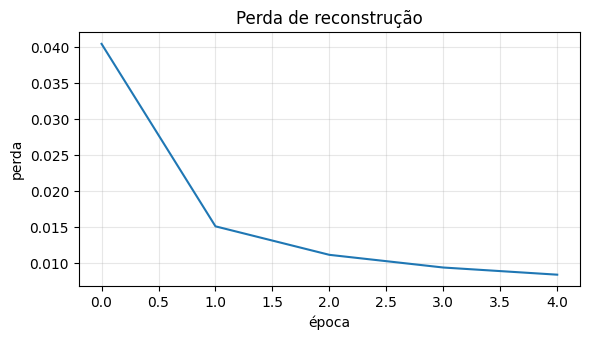

In [7]:
ag.curva(perdas, titulo="Perda de reconstrução")

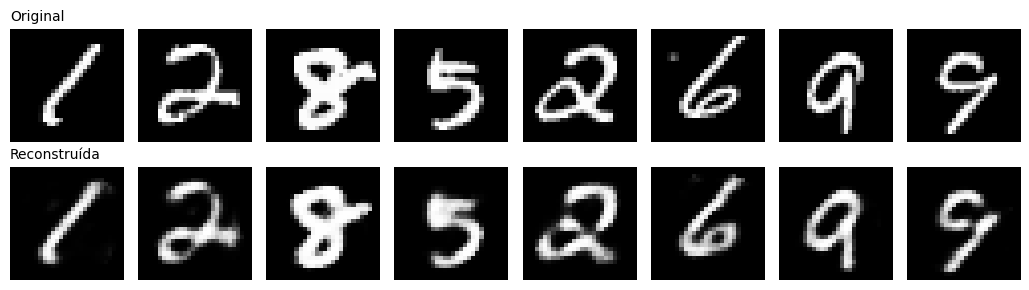

In [8]:
with torch.no_grad():
    reconstruidas = autoencoder(imagens.to(device)).cpu()

ag.comparar_linhas([imagens, reconstruidas], ["Original", "Reconstruída"])

## 5. O espaço latente tem estrutura

Interpolar entre os vetores latentes de dois dígitos gera **transições suaves** — o espaço comprimido organizou os dados por semelhança.

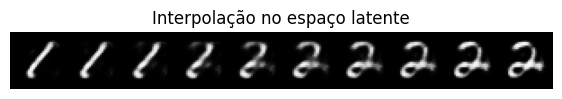

In [9]:
with torch.no_grad():
    z = encoder(imagens[:2].to(device))

caminho = ag.interpolar_latente(decoder, z[0:1], z[1:2], passos=10)
ag.mostrar_grade(caminho, n=10, titulo="Interpolação no espaço latente")

## 6. Autoencoder para remover ruído (*denoising*)

Mudança pequena com efeito grande: a entrada agora é a imagem **com ruído**, mas o alvo continua sendo a imagem **limpa**. A rede é forçada a aprender o que é um dígito de verdade.

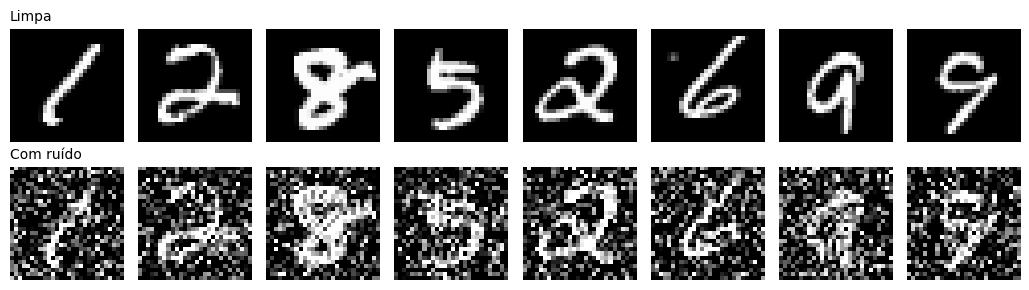

In [10]:
ruidosas = ag.ruido(imagens, intensidade=0.5)
ag.comparar_linhas([imagens, ruidosas], ["Limpa", "Com ruído"])

In [11]:
denoiser = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 32),
    nn.Linear(32, 256), nn.ReLU(), nn.Linear(256, 784), nn.Sigmoid(),
    nn.Unflatten(1, (1, 28, 28)),
).to(device)

otimizador = torch.optim.Adam(denoiser.parameters(), lr=1e-3)

for epoca in range(5):
    soma, n = 0.0, 0
    for x, _ in loader:
        x = x.to(device)
        perda = mse(denoiser(ag.ruido(x)), x)   # entrada ruidosa, alvo limpo
        otimizador.zero_grad(); perda.backward(); otimizador.step()
        soma += perda.item() * x.size(0); n += x.size(0)
    print(f"época {epoca + 1} | perda: {soma / n:.4f}")

época 1 | perda: 0.0489


época 2 | perda: 0.0263


época 3 | perda: 0.0222


época 4 | perda: 0.0201


época 5 | perda: 0.0187


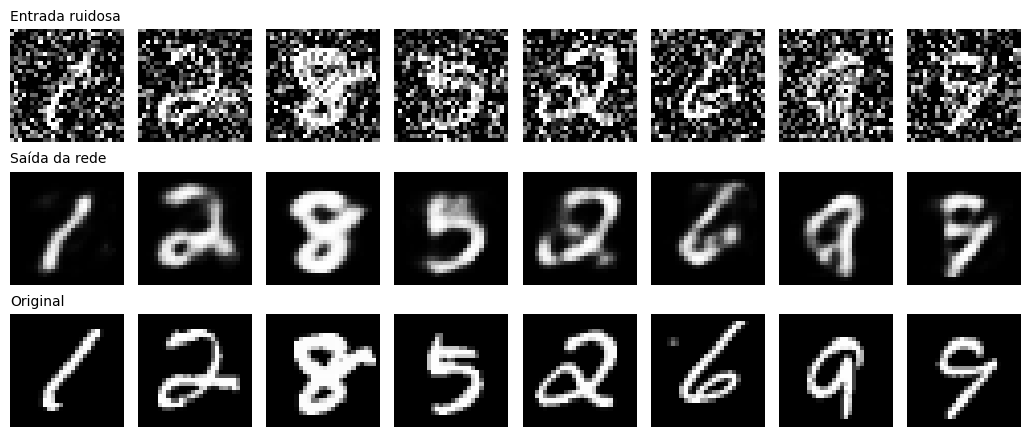

In [12]:
with torch.no_grad():
    limpas = denoiser(ruidosas.to(device)).cpu()

ag.comparar_linhas([ruidosas, limpas, imagens],
                   ["Entrada ruidosa", "Saída da rede", "Original"])

## Exercícios

In [13]:
# TODO Exercício 1: reduza DIM_LATENTE para 2, retreine o autoencoder
# e compare as reconstruções e a interpolação. O que se perde com um
# gargalo tão apertado?

In [14]:
# TODO Exercício 2: aumente a intensidade do ruído para 1.0 e retreine o
# denoiser. Até que nível de ruído a rede ainda recupera os dígitos?

## Resumo e próximos passos

- A arquitetura **encoder–decoder** comprime a entrada em um **espaço latente** e o decoder a reconstrói.
- Autoencoders treinam **sem rótulos**: o alvo é a própria entrada.
- O espaço latente é organizado: interpolações geram transições suaves.
- O *denoising* mostra que a rede aprende a **estrutura** dos dados, não a cópia.
- **Limite:** amostrar o latente ao acaso não produz dígitos novos convincentes — para *gerar* dados precisamos de outra ideia: as **GANs** (Notebook 3).
- Antes, um desvio artístico que usa redes congeladas: **transferência de estilo** (Notebook 2).